Lutas REALIZADO: 969 | Período: 2021-2026
Decisivas: 949 | Title fights: 59

[Q1] Spearman (year vs duration, non-title): rho=-0.008, p=0.8176, n=890

[Q2] Qui-quadrado pre/post-2023: chi2=2.00, p=0.5725, V de Cramer=0.046, n=949

[Q3] Classes analisadas: 9
                      n    mean   std  median
weight_class_clean                           
Heavyweight         208  190.62  6.15  190.50
Light Heavyweight   194  186.72  4.20  185.42
Middleweight         50  184.56  3.47  185.42
Welterweight        284  181.68  5.57  182.88
Lightweight         418  176.57  5.03  177.80
Catchweight         152  175.41  7.48  175.26
Featherweight       326  173.80  4.12  172.72
Bantamweight        163  170.79  4.10  170.18
Flyweight           124  166.04  4.34  165.10

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
        Flyweight  55    0.5818  0.4503   0.7026   0.2806      0.9396        False
    Featherweight 131    0.5191  0.4342  

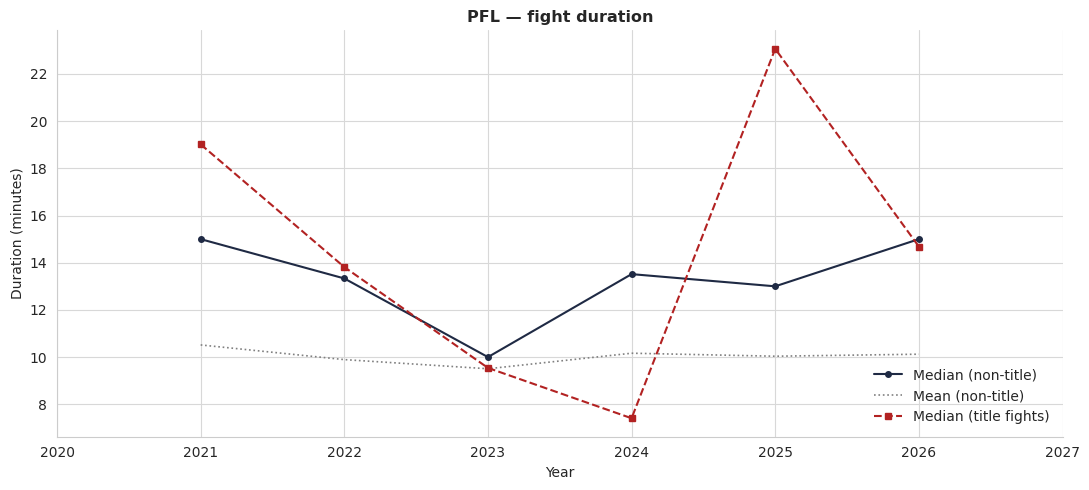

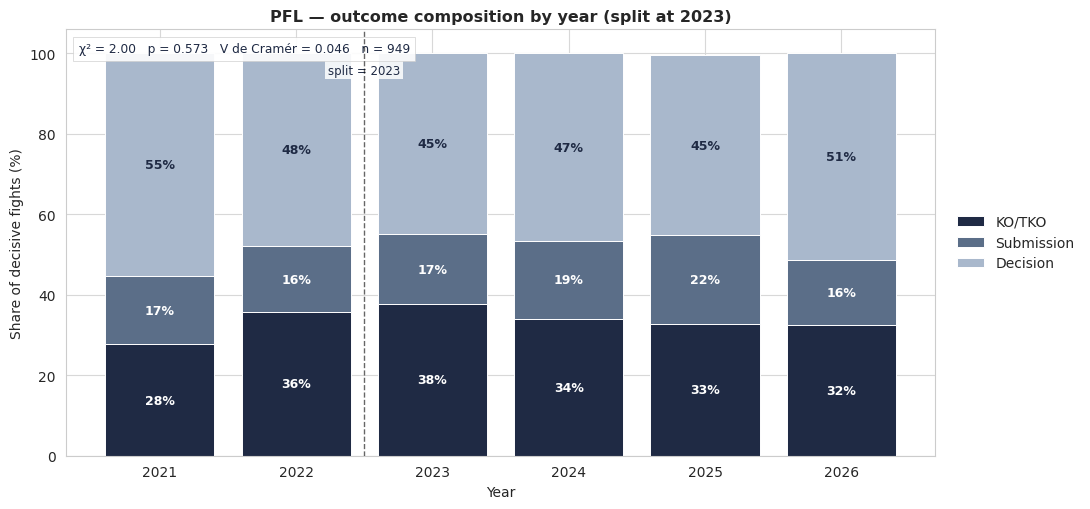

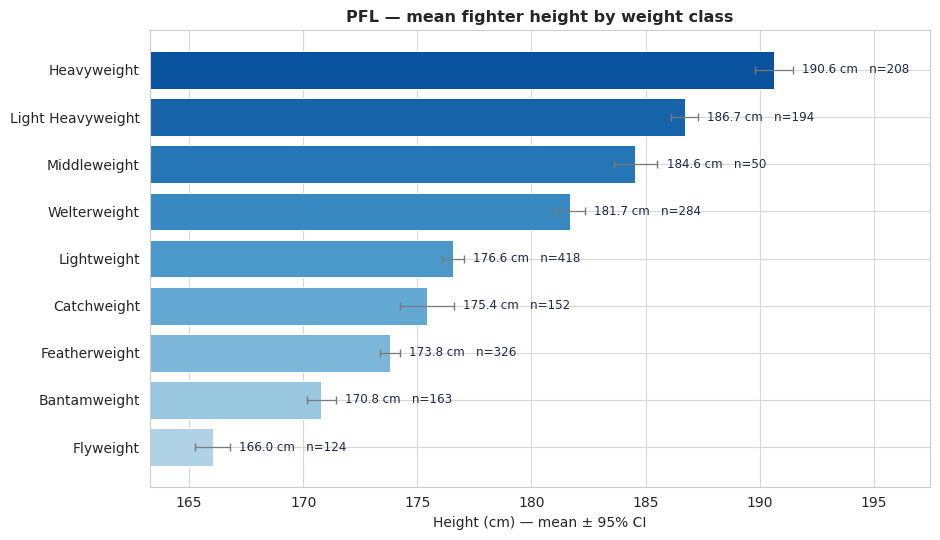

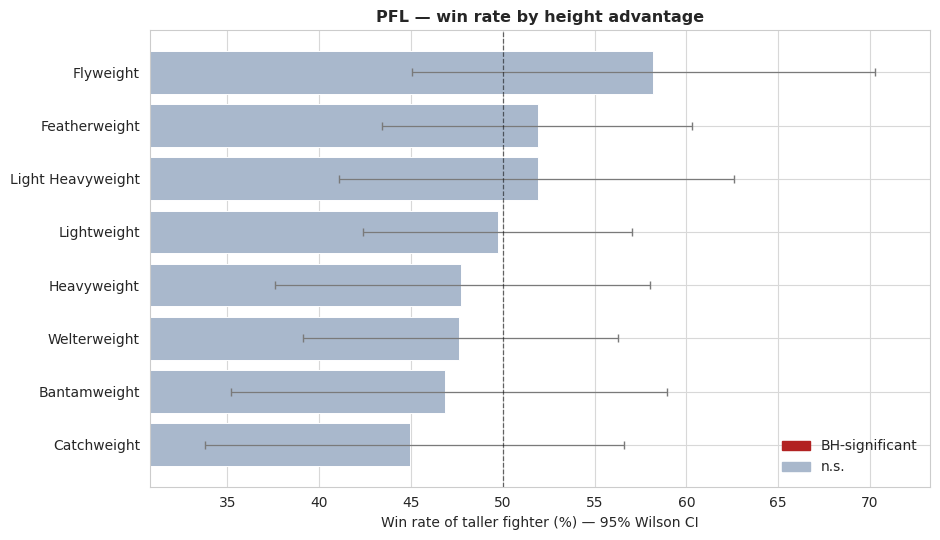

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/pfl-complete-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_pfl.csv'
JSON_PATH = f'{DATA_DIR}/pfl_win_title_data.json'

C_PRIMARY = '#1f2a44'
C_SECONDARY = '#5b6e88'
C_TERTIARY = '#a9b8cc'
C_ACCENT = '#b22222'
C_NEUTRAL = '#7a7a7a'

sns.set_style('whitegrid', {'grid.linewidth': 0.4, 'grid.color': '#d8d8d8'})
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11.5,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 10,
    'legend.frameon': False,
    'figure.dpi': 100,
})


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_pfl():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True,
                                       format='mixed', errors='coerce')
    df = df.dropna(subset=['event_date'])
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            return (int(row['round_num']) - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color=C_PRIMARY,
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color=C_ACCENT,
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('PFL — fight duration')
    ax.legend(loc='lower right')
    ax.set_xlim(df['event_year'].min() - 1, df['event_year'].max() + 1)
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2023):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100
    if props['Other'].max() < 1:
        order = ['KO/TKO', 'Submission', 'Decision']
        props = props[order]

    palette = {'KO/TKO': C_PRIMARY, 'Submission': C_SECONDARY,
               'Decision': C_TERTIARY, 'Other': '#d4d4d4'}

    fig, ax = plt.subplots(figsize=(11, 5.2))
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat,
               color=palette[cat], edgecolor='white', linewidth=0.7)
        for i, (val, b) in enumerate(zip(props[cat].values, bottom)):
            if val >= 5:
                txt_color = 'white' if cat in ('KO/TKO', 'Submission') else C_PRIMARY
                ax.text(props.index[i], b + val / 2, f'{val:.0f}%',
                        ha='center', va='center', color=txt_color,
                        fontsize=9, fontweight='semibold')
        bottom += props[cat].values

    if split_year > props.index.min() and split_year <= props.index.max() + 1:
        ax.axvline(split_year - 0.5, ls='--', color='black',
                   linewidth=1.0, alpha=0.6, zorder=4)
        ax.text(split_year - 0.5, 95, f'split = {split_year}',
                ha='center', fontsize=8.5, color=C_PRIMARY,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))

    rt = res.get('regime_test', {})
    if rt:
        ax.text(0.015, 0.97,
                f"χ² = {rt['chi2']:.2f}   p = {rt['p_value']:.3f}   "
                f"V de Cramér = {rt['cramers_v']:.3f}   n = {rt['n']}",
                transform=ax.transAxes, fontsize=8.8, color=C_PRIMARY,
                verticalalignment='top',
                bbox=dict(facecolor='white', edgecolor='#cccccc',
                          alpha=0.9, pad=4, linewidth=0.5))

    ax.set_xlabel('Year')
    ax.set_ylabel('Share of decisive fights (%)')
    ax.set_title(f'PFL — outcome composition by year (split at {split_year})')
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
    ax.set_ylim(0, 106)
    ax.set_xticks(props.index)
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    desc_sorted = desc.sort_values('mean')
    n = len(desc_sorted)
    cmap = plt.cm.Blues
    colors = [cmap(0.32 + 0.55 * i / max(n - 1, 1)) for i in range(n)]

    se = desc_sorted['std'] / np.sqrt(desc_sorted['n'])
    ci = 1.96 * se
    ax.barh(desc_sorted.index, desc_sorted['mean'], color=colors,
            xerr=ci, edgecolor='white', linewidth=0.7,
            error_kw={'ecolor': C_NEUTRAL, 'linewidth': 0.9, 'capsize': 3})

    xmax = (desc_sorted['mean'] + ci).max() + 6
    xmin = (desc_sorted['mean'] - ci).min() - 2

    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + ci.loc[idx] + 0.4, i,
                f"{row['mean']:.1f} cm   n={int(row['n'])}",
                va='center', fontsize=8.6, color=C_PRIMARY)

    ax.set_xlabel('Height (cm) — mean ± 95% CI')
    ax.set_title('PFL — mean fighter height by weight class')
    ax.set_xlim(xmin, xmax)
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    valid = res[~res['underpowered']].copy().sort_values('win_rate')
    colors = [C_ACCENT if s else C_TERTIARY for s in valid['significant']]

    err_low = (valid['win_rate'] - valid['ci_low']) * 100
    err_high = (valid['ci_high'] - valid['win_rate']) * 100

    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[err_low.values, err_high.values],
            edgecolor='white', linewidth=0.7,
            error_kw={'ecolor': C_NEUTRAL, 'linewidth': 0.9, 'capsize': 3})
    ax.axvline(50, ls='--', color='black', linewidth=0.9, alpha=0.55, zorder=4)

    xmin = max((valid['ci_low'] * 100).min() - 3, 0)
    xmax = (valid['ci_high'] * 100).max() + 3
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('Win rate of taller fighter (%) — 95% Wilson CI')
    ax.set_title('PFL — win rate by height advantage')

    handles = [plt.Rectangle((0, 0), 1, 1, color=C_ACCENT),
               plt.Rectangle((0, 0), 1, 1, color=C_TERTIARY)]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right')
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_pfl()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_pfl_duration.png', dpi=130, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2023)
    fig2.savefig('q2_pfl_outcomes.png', dpi=130, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2023: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_pfl_height.png', dpi=130, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_pfl_height_winrate.png', dpi=130, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
For regular non-title bouts, fight duration is remarkably stable. Throughout the 2021-2026 period, the median is pinned at exactly 10 minutes, with the mean tracking closely alongside. This indicates a high volume of fights either going to decision or deep into the second round. A Spearman correlation (p = 0.817) confirms this flatline trend over the years.

Title fights, on the other hand, show extreme year-to-year volatility—dropping sharply in 2023 and 2024 before spiking in 2025. This is simply a sample-size artifact. With only 59 title bouts spread across six years, a single early finish or a full 25-minute decision drastically skews the annual average. Because the data is so sparse, the title fight trajectory should be viewed as a descriptive overlay rather than a reliable trend.

## Q2 > Outcome Distribution Over Time
The distribution of fight outcomes in the PFL hasn't structurally changed. Comparing the pre- and post-2023 periods yields a non-significant chi-square result (p = 0.573, Cramér's V = 0.046), meaning the mix of finishes remains consistent regardless of the year.

The actual composition is what matters: the PFL leans heavily on decisions. Between 2021 and 2026, 45% to 55% of all decisive fights went to the scorecards. KO/TKOs hovered between 28% and 38%, while submissions were consistently the least common outcome (16% to 22%). This mirrors the modern UFC, reflecting an elite tier of MMA where advanced defensive fundamentals make early finishes difficult to secure.

## Q3 > Mean Height by Weight Class
As expected, average heights scale predictably with the weight classes, moving from Flyweight (166.0 cm) up to Heavyweight (190.6 cm).

The measurements point to physical standards typical of top-tier international promotions. The middle and lower divisions, in particular, show very tight distributions. Middleweights, for example, average 184.6 cm with a standard deviation of just 3.47 cm. This low variance means athletes in these classes have highly optimized, virtually interchangeable physical frames for their weight limits.

The Catchweight group (175.4 cm) sits right between Lightweight and Featherweight. This makes sense mechanically, as it mostly aggregates athletes taking short-notice fights or missing weight near the 145lb and 155lb marks.

## Q4 > Win Rate by Height Advantage
The idea that height provides a distinct competitive edge doesn't hold up in the PFL data. Across the eight weight classes with a sufficient sample size (n ≥ 30), the win rate for the taller fighter never reaches statistical significance after the Benjamini-Hochberg correction.

Instead of favoring the taller athlete, the results hover around a coin toss. Flyweights showed the highest win rate for taller fighters (58.2%), but in heavier classes like Heavyweight, Welterweight, and Bantamweight, taller athletes actually lost slightly more often than they won. The Lightweight division sits right at the null (49.7%).

Because every 95% Wilson confidence interval crosses the 50% line, the data indicates that height offers no measurable advantage here. Any distance management benefits seem to be completely neutralized by the mechanical advantages of a shorter stature, such as a lower center of gravity, better wrestling leverage, and faster speed inside the pocket.